-------------------------------------------------------------
## Viken KHATCHERIAN
## Formation AI Engineer
## Openclassrooms
## Projet 4 : classifiez automatiquement des informations
-------------------------------------------------------------

## Partie 1 - Etape préalable

In [410]:
# Contrôle présence venv uv 
import sys
print(sys.executable)

/mnt/projects/ai_engineer_projects/P04/.venv/bin/python3


In [411]:
# Contrôle version python
sys.version

'3.11.15 (main, Mar 10 2026, 18:16:52) [Clang 21.1.4 ]'

In [412]:
# Contrôle présence des bibliothèques installées dans le venv uv
import importlib.metadata as md

packages = [
    "imbalanced-learn", "ipykernel", "jupyterlab",
    "matplotlib", "missingno", "numpy", "pandas", 
    "plotly", "psycopg2-binary", "pyarrow" , "scikit-learn",
    "scipy", "seaborn", "shap", "sqlalchemy", "statsmodels"
]

for p in packages:
    try:
        print(p, md.version(p))
    except:
        print(p, "missing")

imbalanced-learn 0.14.1
ipykernel 7.2.0
jupyterlab 4.5.6
matplotlib 3.10.8
missingno 0.5.2
numpy 2.4.3
pandas 3.0.1
plotly 6.6.0
psycopg2-binary 2.9.11
pyarrow 23.0.1
scikit-learn 1.8.0
scipy 1.17.1
seaborn 0.13.2
shap 0.51.0
sqlalchemy 2.0.48
statsmodels 0.14.6


## Partie 2 - Etape 1 : Effectuer une analyse exploratoire des fichiers de données

#### EDA du dataframe df_sirh avant jointure

In [413]:
# Chargement en dataframes pandas des 3 fichiers sources sirh, évaluation et sondage  
import pandas as pd

In [414]:
df_sirh = pd.read_csv("../data/raw/extrait_sirh.csv")

In [415]:
df_sirh.head(3)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0


In [416]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        1470 non-null   int64
 11  annees_dans_le_poste_actuel     1470 non-null   int64
dtypes: int64(8), str(4)
memory usage: 191.1 KB


In [417]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_sirh.rename(columns={
    "id_employee": "id_salarie",
    "nombre_heures_travailless": "nombre_heures_travaillees",
    "annee_experience_totale" : "nombre_total_annees_experience",
    "annees_dans_l_entreprise" : "nombre_total_annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel" : "nombre_total_annees_dans_le_poste_actuel"  
}, inplace=True)

In [418]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   id_salarie                                1470 non-null   int64
 1   age                                       1470 non-null   int64
 2   genre                                     1470 non-null   str  
 3   revenu_mensuel                            1470 non-null   int64
 4   statut_marital                            1470 non-null   str  
 5   departement                               1470 non-null   str  
 6   poste                                     1470 non-null   str  
 7   nombre_experiences_precedentes            1470 non-null   int64
 8   nombre_heures_travaillees                 1470 non-null   int64
 9   nombre_total_annees_experience            1470 non-null   int64
 10  nombre_total_annees_dans_l_entreprise     1470 non-null   int64
 11  no

In [419]:
# identification des colonnes numériques
int_cols_sirh = df_sirh.select_dtypes(include="int64").columns
print(int_cols_sirh)

Index(['id_salarie', 'age', 'revenu_mensuel', 'nombre_experiences_precedentes',
       'nombre_heures_travaillees', 'nombre_total_annees_experience',
       'nombre_total_annees_dans_l_entreprise',
       'nombre_total_annees_dans_le_poste_actuel'],
      dtype='str')


In [420]:
# Vérification absence de decimales sur les valeurs au format int64
for col in int_cols_sirh:
    a_decimales = (df_sirh[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

id_salarie a décimales ? False
age a décimales ? False
revenu_mensuel a décimales ? False
nombre_experiences_precedentes a décimales ? False
nombre_heures_travaillees a décimales ? False
nombre_total_annees_experience a décimales ? False
nombre_total_annees_dans_l_entreprise a décimales ? False
nombre_total_annees_dans_le_poste_actuel a décimales ? False


In [421]:
# Identification des colonnes type chaînes de caractères
string_cols_sirh = df_sirh.select_dtypes(include="str").columns
print(string_cols_sirh)

Index(['genre', 'statut_marital', 'departement', 'poste'], dtype='str')


In [422]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_sirh:
    print(df_sirh[col].unique()) 

<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str
<ArrowStringArray>
['Célibataire', 'Marié(e)', 'Divorcé(e)']
Length: 3, dtype: str
<ArrowStringArray>
['Commercial', 'Consulting', 'Ressources Humaines']
Length: 3, dtype: str
<ArrowStringArray>
[       'Cadre Commercial',  'Assistant de Direction',
              'Consultant',               'Tech Lead',
                 'Manager',          'Senior Manager',
 'Représentant Commercial',     'Directeur Technique',
     'Ressources Humaines']
Length: 9, dtype: str


In [423]:
# Retirer les majuscules, espaces, accents et parenthèses
import unicodedata

df_sirh[string_cols_sirh] = df_sirh[string_cols_sirh].apply(
    lambda string_cols_sirh: string_cols_sirh.astype(str)
    .str.lower()
    .str.replace(r"[()]", "", regex=True)  
    .str.replace(" ", "_")
    .str.strip("_") 
    .map(lambda x: unicodedata.normalize("NFKD", x)
         .encode("ascii", errors="ignore")
         .decode("utf-8"))
)

In [424]:
# Réafficher les colonnes types chaînes de caractères mises en forme
for col in string_cols_sirh:
    print(df_sirh[col].unique()) 

<ArrowStringArray>
['f', 'm']
Length: 2, dtype: str
<ArrowStringArray>
['celibataire', 'mariee', 'divorcee']
Length: 3, dtype: str
<ArrowStringArray>
['commercial', 'consulting', 'ressources_humaines']
Length: 3, dtype: str
<ArrowStringArray>
[       'cadre_commercial',  'assistant_de_direction',
              'consultant',               'tech_lead',
                 'manager',          'senior_manager',
 'representant_commercial',     'directeur_technique',
     'ressources_humaines']
Length: 9, dtype: str


In [425]:
# Recherche de valeurs manquantes 
df_sirh.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

id_salarie                                  0
age                                         0
genre                                       0
revenu_mensuel                              0
statut_marital                              0
departement                                 0
poste                                       0
nombre_experiences_precedentes              0
nombre_heures_travaillees                   0
nombre_total_annees_experience              0
nombre_total_annees_dans_l_entreprise       0
nombre_total_annees_dans_le_poste_actuel    0
dtype: int64

In [426]:
# Contrôle présence de doublons sur la colonne id_salarie
df_sirh["id_salarie"].duplicated().any()

np.False_

In [427]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   id_salarie                                1470 non-null   int64
 1   age                                       1470 non-null   int64
 2   genre                                     1470 non-null   str  
 3   revenu_mensuel                            1470 non-null   int64
 4   statut_marital                            1470 non-null   str  
 5   departement                               1470 non-null   str  
 6   poste                                     1470 non-null   str  
 7   nombre_experiences_precedentes            1470 non-null   int64
 8   nombre_heures_travaillees                 1470 non-null   int64
 9   nombre_total_annees_experience            1470 non-null   int64
 10  nombre_total_annees_dans_l_entreprise     1470 non-null   int64
 11  no

In [428]:
# Statistiques descriptives du dataframe df_sirh
df_sirh.describe()

,id_salarie,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travaillees,nombre_total_annees_experience,nombre_total_annees_dans_l_entreprise,nombre_total_annees_dans_le_poste_actuel
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000
mean,1024.865306,36.923810,6502.931293,2.693197,80.0,11.279592,7.008163,4.229252
std,602.024335,9.135373,4707.956783,2.498009,0.0,7.780782,6.126525,3.623137
min,1.000000,18.000000,1009.000000,0.000000,80.0,0.000000,0.000000,0.000000
25%,491.250000,30.000000,2911.000000,1.000000,80.0,6.000000,3.000000,2.000000
50%,1020.500000,36.000000,4919.000000,2.000000,80.0,10.000000,5.000000,3.000000
75%,1555.750000,43.000000,8379.000000,4.000000,80.0,15.000000,9.000000,7.000000
max,2068.000000,60.000000,19999.000000,9.000000,80.0,40.000000,40.000000,18.000000


### premiere analyse des statistiques descriptives
* anomalies du nombre d'heures travaillées car tous les salariés sont à 80h soit plus de deux fois 35h => cette colonne est peu informative et pourra donc être ignorée
*  la moyenne d'âge des salariés est de 36 ans
*  la distribution des âges des salariés est équilibrée car moyenne = médiane
*  le nombre d'années moyen passées dans l'entreprise est autour de **7 ans**

In [429]:
# suppression de la colonne nombre d'heures travaillées
df_sirh.drop(columns=["nombre_heures_travaillees"], inplace=True)

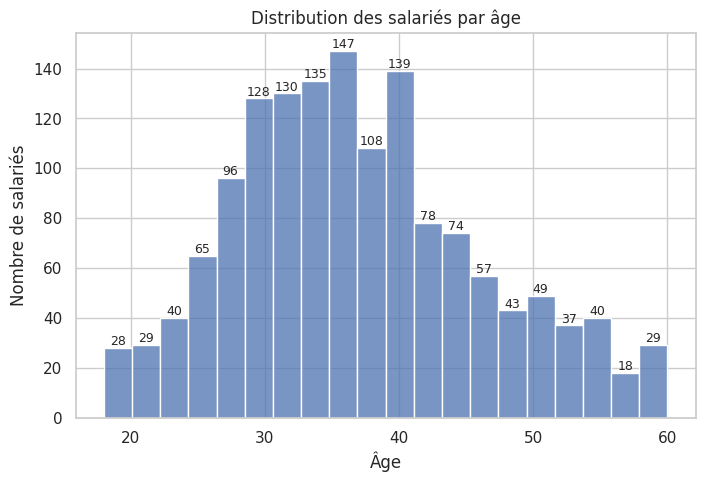

In [430]:
# distribution des âges des salariés

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["age"], bins=20)

plt.title("Distribution des salariés par âge")
plt.xlabel("Âge")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

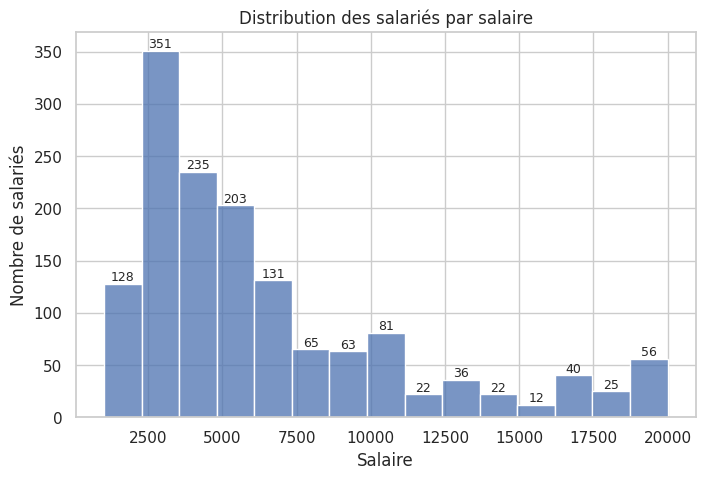

In [431]:
# distribution des revenus mensuels
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["revenu_mensuel"], bins=15)

plt.title("Distribution des salariés par salaire")
plt.xlabel("Salaire")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

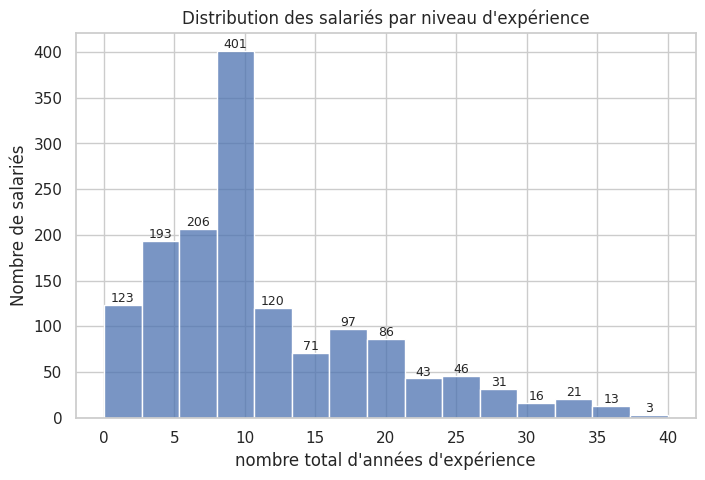

In [432]:
#  Distribution du nombre total d'annees d'experience 
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["nombre_total_annees_experience"], bins=15)

plt.title("Distribution des salariés par niveau d'expérience")
plt.xlabel("nombre total d'années d'expérience")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

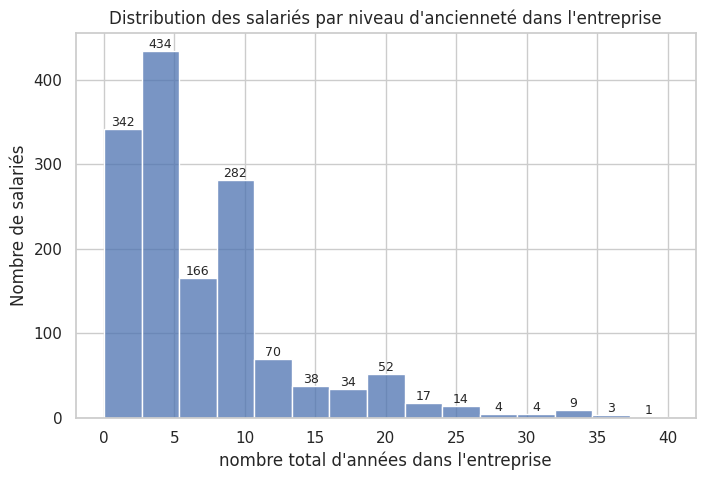

In [433]:
# Distribution du niveau d'ancienneté dans l'entreprise
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["nombre_total_annees_dans_l_entreprise"], bins=15)

plt.title("Distribution des salariés par niveau d'ancienneté dans l'entreprise")
plt.xlabel("nombre total d'années dans l'entreprise")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

### observations
* le salaire médian de 4 900 € représente le cœur de la population salariale
* la majorité des salariés quittent avant 10 ans
* peu de salariés atteignent donc les niveaux d’ancienneté élevés
* cela peut limiter la progression salariale globale et **potentiellement influencer le turnover**

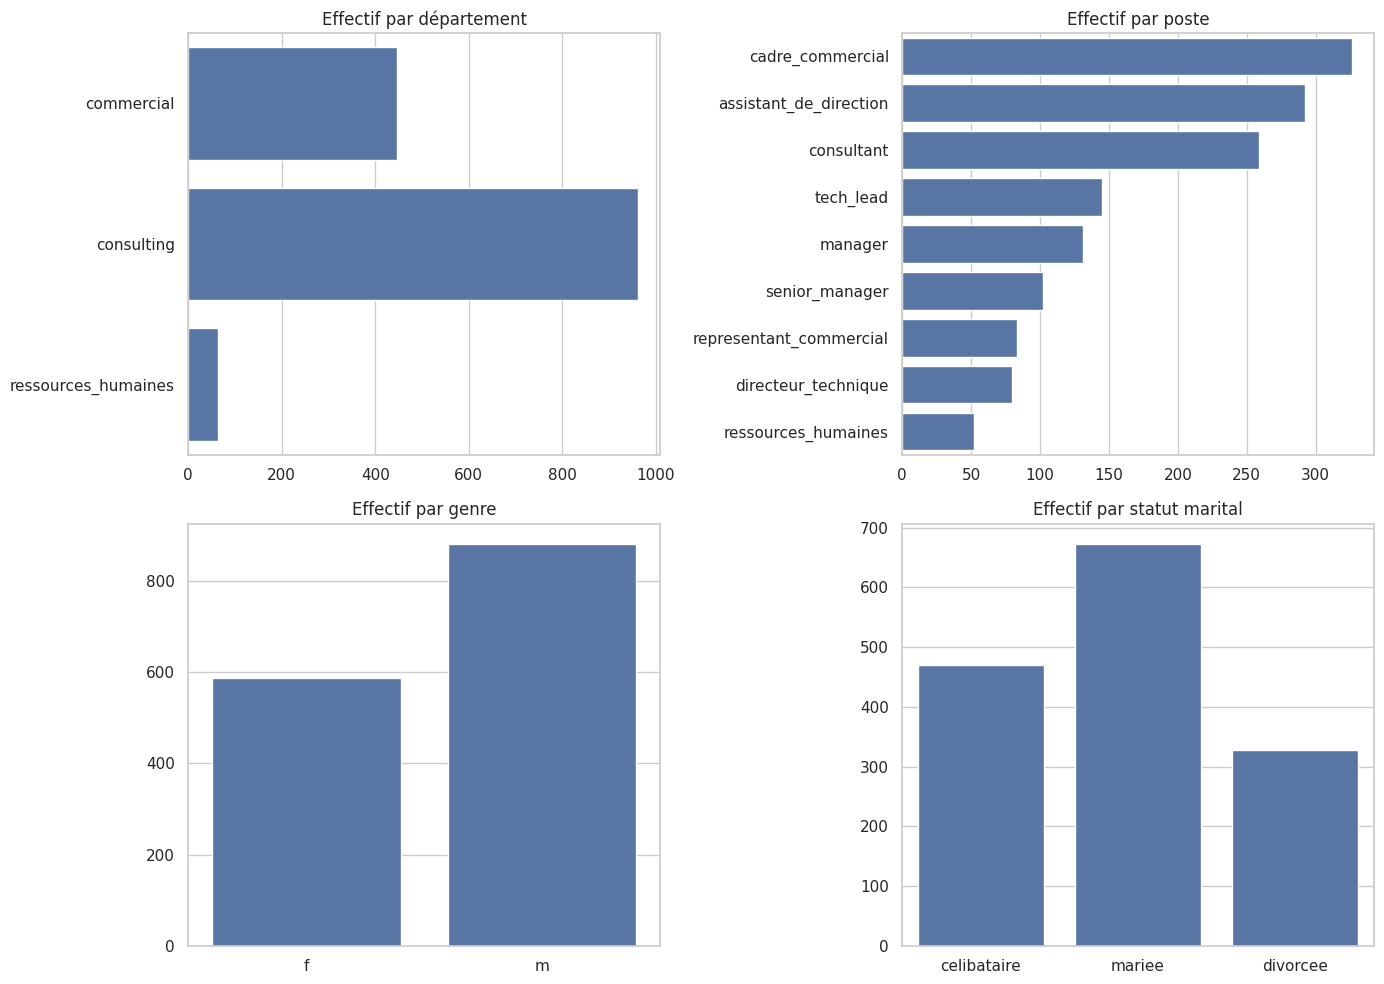

In [434]:
# Distribution par département, poste, genre et statut marital

import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    ("departement", "Effectif par département", "y"),
    ("poste", "Effectif par poste", "y"),
    ("genre", "Effectif par genre", "x"),
    ("statut_marital", "Effectif par statut marital", "x")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, title, orient) in enumerate(cols):
    
    if orient == "y":
        sns.countplot(y=df_sirh[col], ax=axes[i])
    else:
        sns.countplot(x=df_sirh[col], ax=axes[i])
    
    axes[i].set_title(title)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

### observations
* les postes de cadre commercial, assistant de direction et de consultant sont les plus représentés
* il n'y a pas de déséquilibre profond entre hommes et femmes bien que ces dernières soient à 25% moins représentées que les hommes

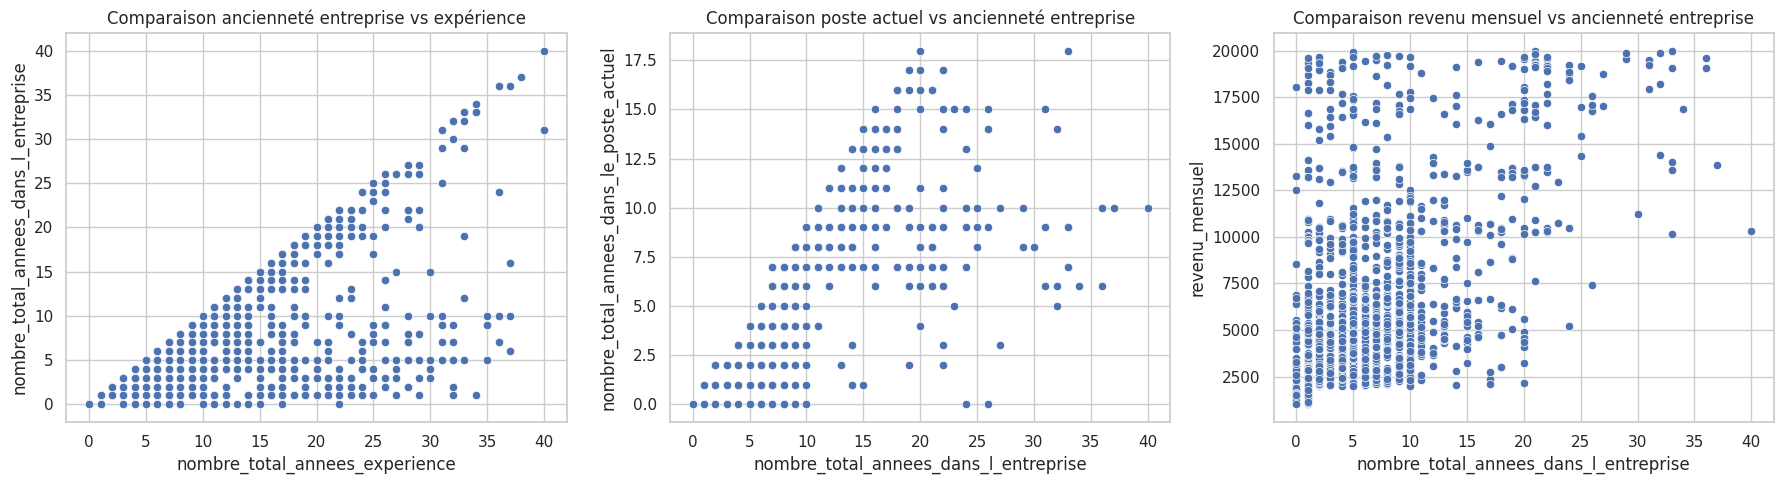

In [435]:
# Recherche de premieres corrélations
import matplotlib.pyplot as plt
import seaborn as sns

plots = [
    (
        "nombre_total_annees_experience",
        "nombre_total_annees_dans_l_entreprise",
        "Comparaison ancienneté entreprise vs expérience"
    ),
    (
        "nombre_total_annees_dans_l_entreprise",
        "nombre_total_annees_dans_le_poste_actuel",
        "Comparaison poste actuel vs ancienneté entreprise"
    ),
    (
        "nombre_total_annees_dans_l_entreprise",
        "revenu_mensuel",
        "Comparaison revenu mensuel vs ancienneté entreprise"
    )
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (x, y, title) in enumerate(plots):
    sns.scatterplot(
        data=df_sirh,
        x=x,
        y=y,
        ax=axes[i]
    )
    axes[i].set_title(title)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

plt.tight_layout()
plt.show()

### observations
* les salariés arrivent dans l'entreprise avec de l'entreprise déjà acquise ailleurs
* les salariés dans l'entreprise changent régulièrement de poste ce qui peut signifier soit **promotions** soit **restructurations fréquentes**

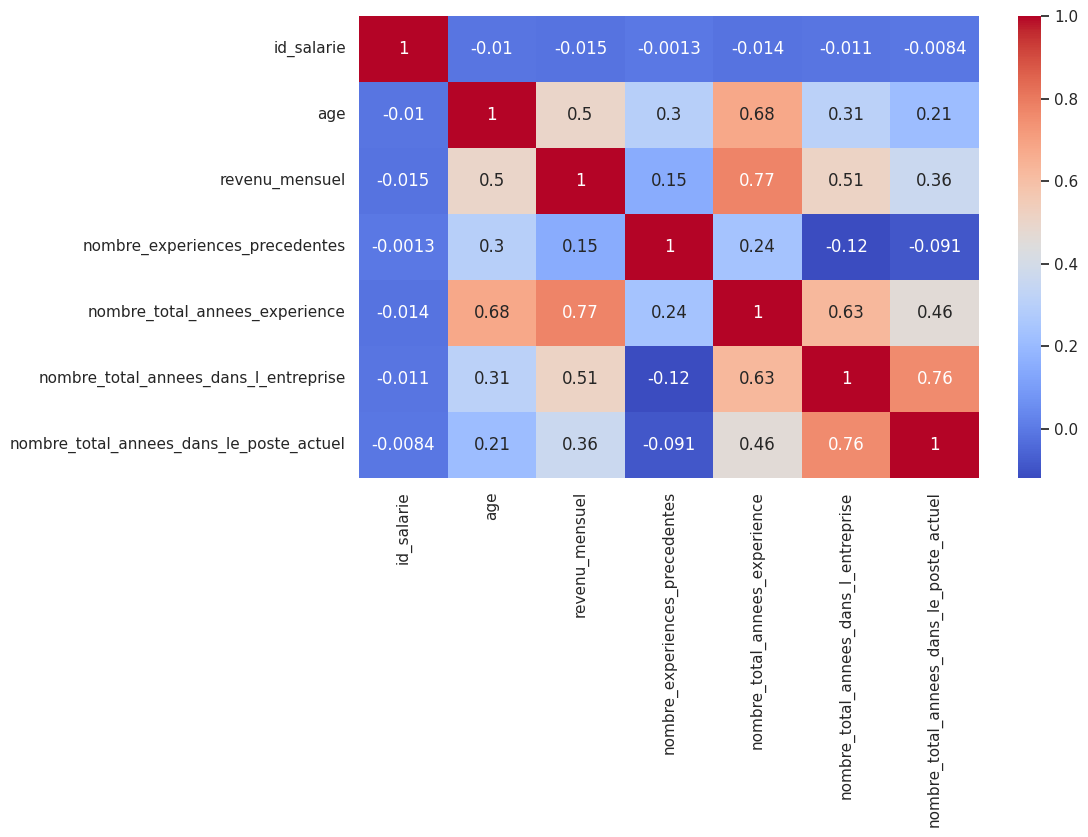

In [436]:
# Matrice globale des corrélations de df_sirh
plt.figure(figsize=(10,6))
sns.heatmap(df_sirh.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

### observartions de la heatmap
Les variables suivantes sont fortement corrélées entre elles
* l'âge augmente avec l'expérience
* l'expérience augmente avec le salaire 
* l'ancienneté augmente sans nécessairement changer de poste (soit f**aible mobilité interne pouvant epxliquer les départs** soit **évolution lente**)

Ces variables corrélées amènent de la **multicolinéarité ** qui peut rendre les **poids instables** et **l'interprétation biaisée** dans une modélisaiton de machine learning. Il faudra donc:
* soit garder soit âge
* soit expérience
* ou créer une feature “ratio salaire / expérience”

#### EDA du dataframe df_eval avant jointure

In [437]:
df_eval = pd.read_csv("../data/raw/extrait_eval.csv")

In [438]:
df_eval.head(3)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %


In [439]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 132.9 KB


In [440]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_eval.rename(columns={
    "satisfaction_employee_environnement": "satisfaction_salarie_environnement",
    "satisfaction_employee_nature_travail": "satisfaction_salarie_nature_travail",
    "satisfaction_employee_equipe": "satisfaction_salarie_equipe",
    "satisfaction_employee_equilibre_pro_perso" : "satisfaction_salarie_equilibre_pro_perso",
    "eval_number" : "numero_d_evaluation",
    "heure_supplementaires" : "heures_supplementaires",
    "augementation_salaire_precedente" : "precedent_pourcentage_d_augmentation"  
}, inplace=True)

In [441]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   str  
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 132.9 KB


In [442]:
int_cols_eval = df_eval.select_dtypes(include="int64").columns
print(int_cols_eval)

Index(['satisfaction_salarie_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_salarie_nature_travail',
       'satisfaction_salarie_equipe',
       'satisfaction_salarie_equilibre_pro_perso', 'note_evaluation_actuelle'],
      dtype='str')


In [443]:
for col in int_cols_eval:
    a_decimales = (df_eval[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

satisfaction_salarie_environnement a décimales ? False
note_evaluation_precedente a décimales ? False
niveau_hierarchique_poste a décimales ? False
satisfaction_salarie_nature_travail a décimales ? False
satisfaction_salarie_equipe a décimales ? False
satisfaction_salarie_equilibre_pro_perso a décimales ? False
note_evaluation_actuelle a décimales ? False


In [444]:
# Identification des colonnes type chaînes de caractères
string_cols_eval = df_eval.select_dtypes(include="str").columns
print(string_cols_eval)

Index(['numero_d_evaluation', 'heures_supplementaires',
       'precedent_pourcentage_d_augmentation'],
      dtype='str')


In [445]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_eval:
    print(df_eval[col].unique()) 

<ArrowStringArray>
[   'E_1',    'E_2',    'E_4',    'E_5',    'E_7',    'E_8',   'E_10',
   'E_11',   'E_12',   'E_13',
 ...
 'E_2054', 'E_2055', 'E_2056', 'E_2057', 'E_2060', 'E_2061', 'E_2062',
 'E_2064', 'E_2065', 'E_2068']
Length: 1470, dtype: str
<ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
<ArrowStringArray>
['11 %', '23 %', '15 %', '12 %', '13 %', '20 %', '22 %', '21 %', '17 %',
 '14 %', '16 %', '18 %', '19 %', '24 %', '25 %']
Length: 15, dtype: str


In [446]:
df_sirh["id_salarie"].min(), df_sirh["id_salarie"].max()

(np.int64(1), np.int64(2068))

In [447]:
# Transformer les colonnes au format int64 
import re

df_eval["numero_d_evaluation"] = df_eval["numero_d_evaluation"].apply(
    lambda x: int(re.sub(r"\D", "", str(x)))
)

df_eval["heures_supplementaires"] = df_eval["heures_supplementaires"].apply(
    lambda x: str(x).strip().lower()
)

df_eval["precedent_pourcentage_d_augmentation"] = df_eval["precedent_pourcentage_d_augmentation"].apply(
    lambda x: int(re.sub(r"[^\d]", "", str(x)))
)

In [448]:
for col in string_cols_eval:
    print(df_eval[col].unique()) 

[   1    2    4 ... 2064 2065 2068]
<ArrowStringArray>
['oui', 'non']
Length: 2, dtype: str
[11 23 15 12 13 20 22 21 17 14 16 18 19 24 25]


In [449]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   int64
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64
dtypes: int64(9), str(1)
memory usage: 119.3 KB


In [450]:
# Recherche de valeurs manquantes 
df_eval.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

satisfaction_salarie_environnement          0
note_evaluation_precedente                  0
niveau_hierarchique_poste                   0
satisfaction_salarie_nature_travail         0
satisfaction_salarie_equipe                 0
satisfaction_salarie_equilibre_pro_perso    0
numero_d_evaluation                         0
note_evaluation_actuelle                    0
heures_supplementaires                      0
precedent_pourcentage_d_augmentation        0
dtype: int64

In [451]:
# Contrôle présence de doublons sur la colonne numero_d_evaluation
df_eval["numero_d_evaluation"].duplicated().any()

np.False_

In [452]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   int64
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64
dtypes: int64(9), str(1)
memory usage: 119.3 KB


In [453]:
# Statistiques descriptives du dataframe df_eval
num_cols_eval = df_eval.select_dtypes(include="int64").columns
cat_cols_eval = df_eval.select_dtypes(include="str").columns
df_eval[num_cols_eval].describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_salarie_environnement,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
satisfaction_salarie_nature_travail,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0
satisfaction_salarie_equipe,1470.0,2.712245,1.081209,1.0,2.00,3.0,4.00,4.0
satisfaction_salarie_equilibre_pro_perso,1470.0,2.761224,0.706476,1.0,2.00,3.0,3.00,4.0
numero_d_evaluation,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
note_evaluation_actuelle,1470.0,3.153741,0.360824,3.0,3.00,3.0,3.00,4.0
precedent_pourcentage_d_augmentation,1470.0,15.209524,3.659938,11.0,12.00,14.0,18.00,25.0


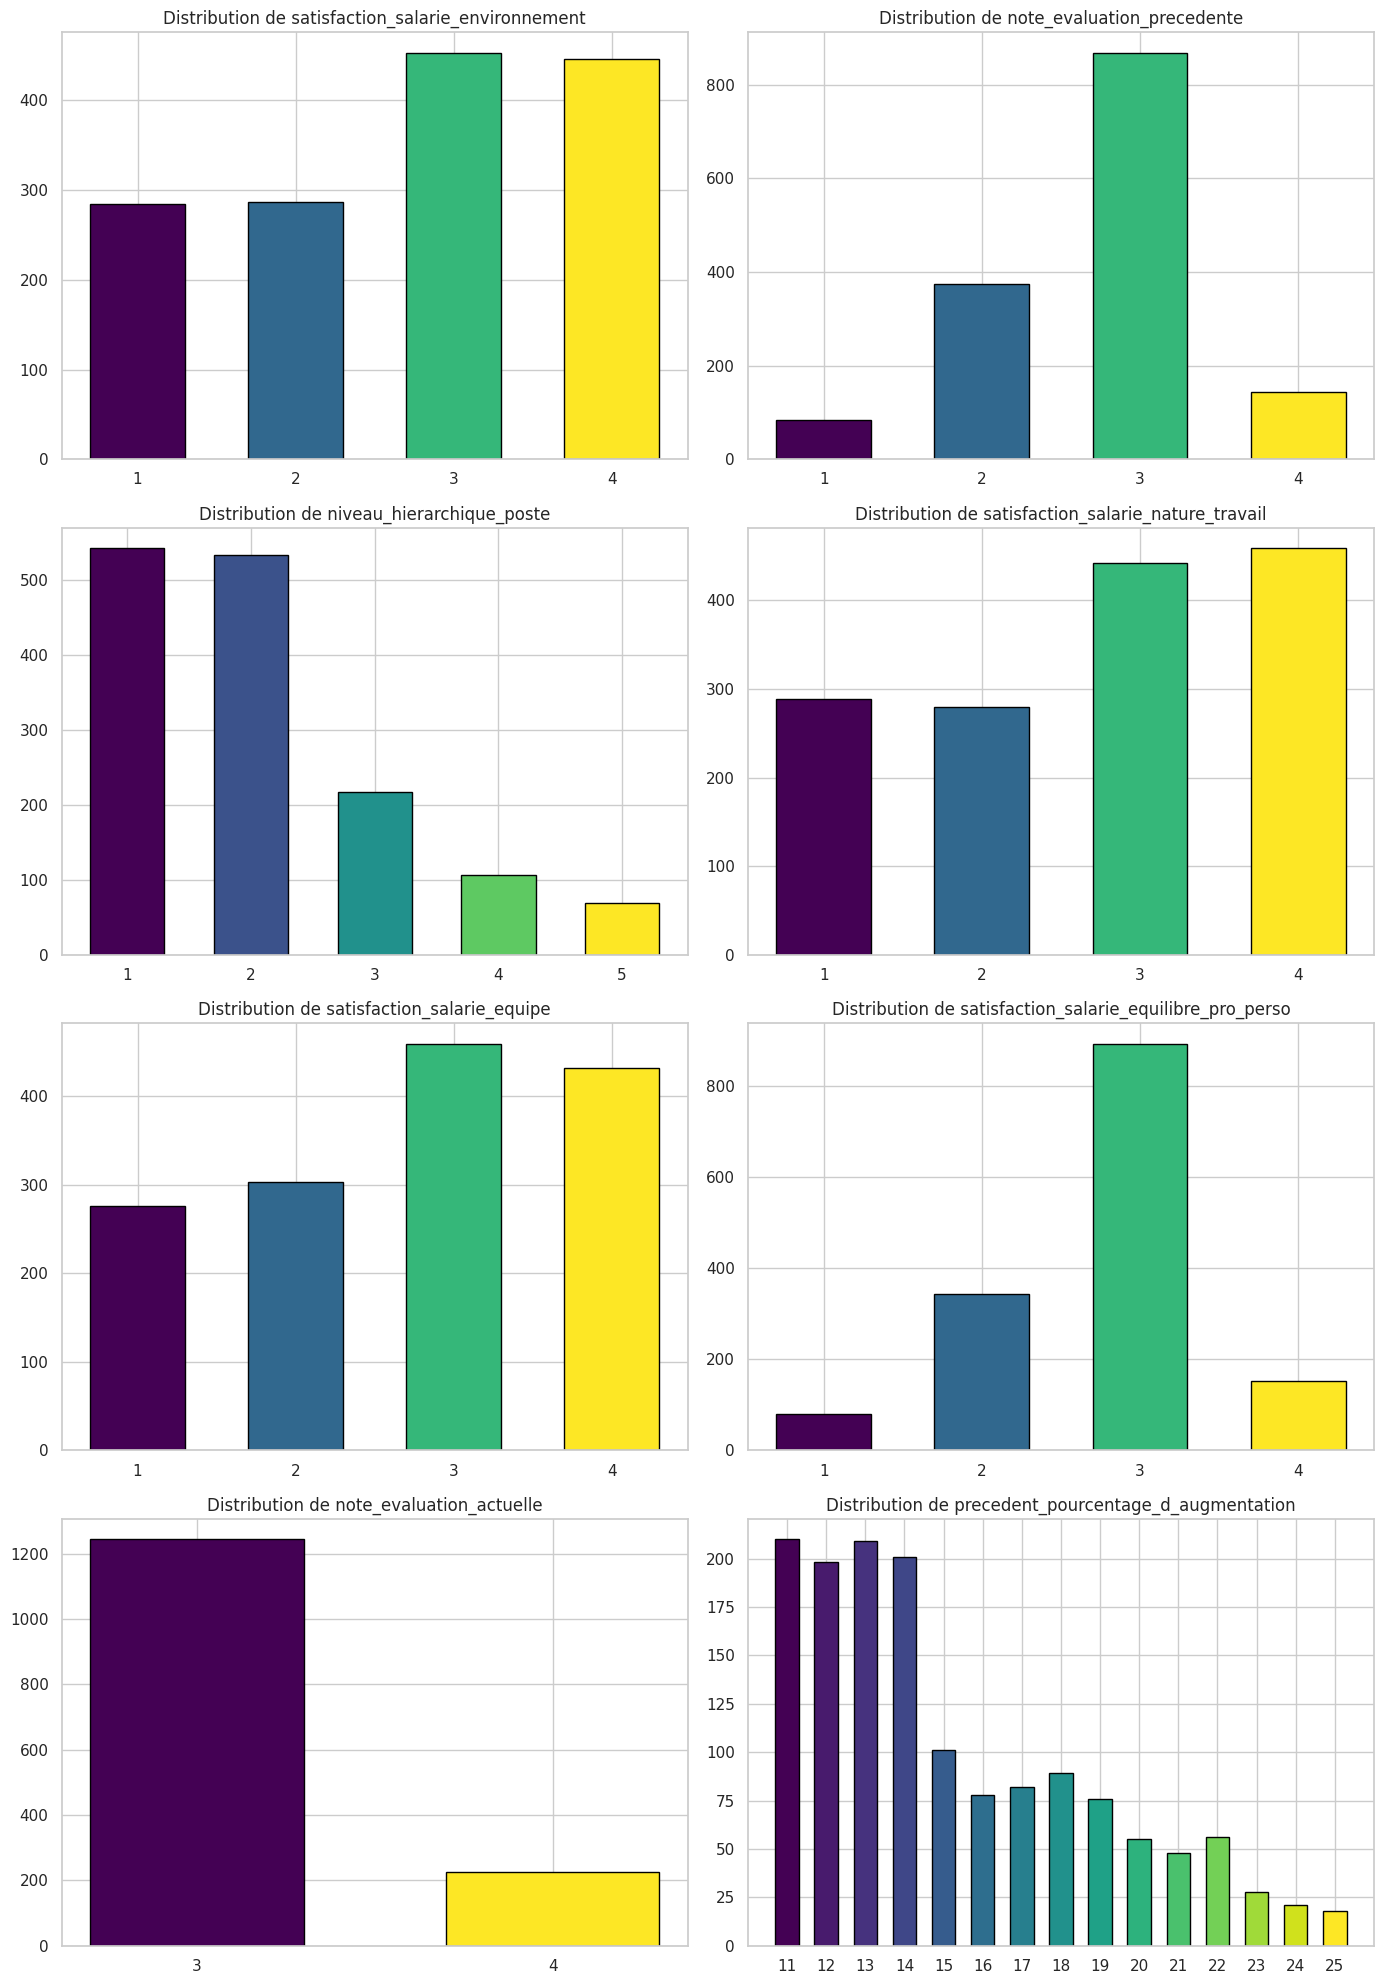

In [454]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math

hierarchical_cols = ["niveau_hierarchique_poste"]
percent_cols = ["precedent_pourcentage_d_augmentation"]
exclude_cols = ["numero_d_evaluation"] 

# on retire la colonne du calcul
cols_to_plot = [col for col in num_cols_eval if col not in exclude_cols]

n_cols = 2
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.ravel()

cmap = plt.cm.viridis

for i, col in enumerate(cols_to_plot):

    # cas niveau hiérarchique
    if col in hierarchical_cols:
        levels = sorted(df_eval[col].unique())

    # cas pourcentage augmentation
    elif col in percent_cols:
        levels = sorted(df_eval[col].unique())
        axes[i].set_xlim(min(levels) - 1, max(levels) + 1)

    # autres variables numériques
    else:
        levels = sorted(df_eval[col].unique())

    # normalisation couleurs
    norm = mcolors.Normalize(vmin=min(levels), vmax=max(levels))

    counts = df_eval[col].value_counts().reindex(levels, fill_value=0)

    colors = [cmap(norm(x)) for x in counts.index]

    axes[i].bar(
        counts.index,
        counts.values,
        width=0.6,
        edgecolor="black",
        color=colors
    )

    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xticks(levels)

# supprimer axes inutilisés
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

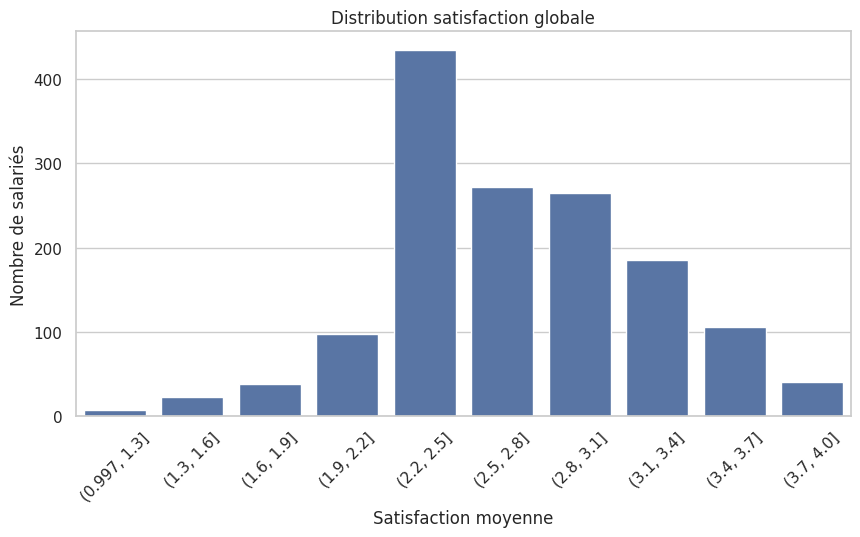

In [455]:

# création de la satisfaction moyenne
satisfaction_cols = [
    "satisfaction_salarie_environnement",
    "satisfaction_salarie_nature_travail",
    "satisfaction_salarie_equipe",
    "satisfaction_salarie_equilibre_pro_perso"
]

df_eval["satisfaction_moyenne"] = df_eval[satisfaction_cols].mean(axis=1)

# création des bins
df_eval["satisfaction_bin"] = pd.cut(
    df_eval["satisfaction_moyenne"],
    bins=10
)

# comptage par bin
bar_data = df_eval["satisfaction_bin"].value_counts().sort_index()

# barplot
plt.figure(figsize=(10,5))
sns.barplot(x=bar_data.index.astype(str), y=bar_data.values)

plt.xticks(rotation=45)
plt.title("Distribution satisfaction globale")
plt.xlabel("Satisfaction moyenne")
plt.ylabel("Nombre de salariés")

plt.show()

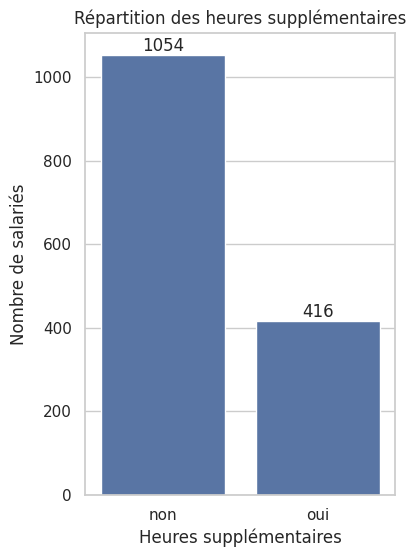

In [456]:
# distribution des heures supplémentaires

plt.figure(figsize=(4,6))

ax = sns.countplot(
    data=df_eval,
    x="heures_supplementaires",
    order=["non", "oui"] 
)

# titres
plt.title("Répartition des heures supplémentaires")
plt.xlabel("Heures supplémentaires")
plt.ylabel("Nombre de salariés")

# ajout des valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container)

plt.show()

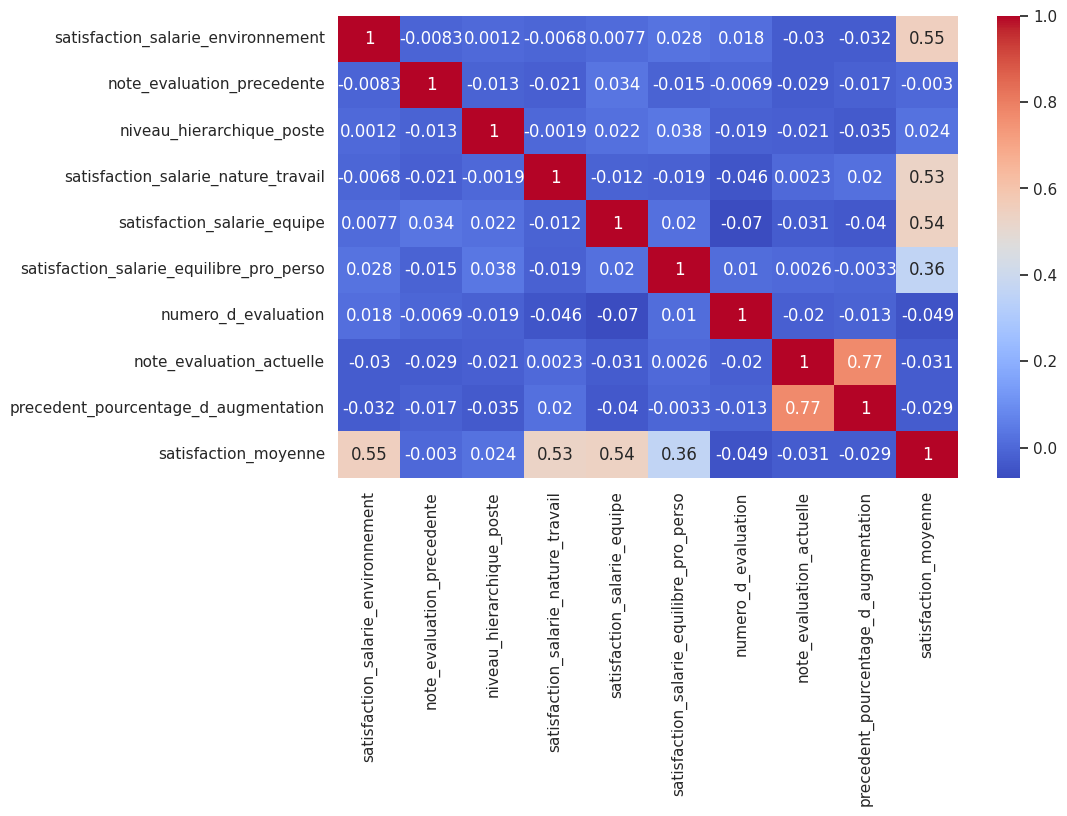

In [457]:
# matrice globale des corrélations de df_eval
plt.figure(figsize=(10,6))
sns.heatmap(df_eval.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

#### observations
* satisfaction globale moyenne mais pas excellente
* peu de différenciation individuelle sur l'augmentation salariale
* perception de l'environnement de travail globalement bonne mais pas homogène (400 personnes note 3 et 400 personnes note 4) ce qui peut cacher des différences dans les différents départements de travail
* le système de notation d'évaluation actuelle est peu discriminant par près de 80%  des salariés ont leur performance notée à 3. Or 400 salariés evaluent la satisfaction globale à 2 ce qui montre que les salariés évaluent moins bien leur bien-être (pouvant causer des départs) que leur performance ce qui est synonyme de stress global.
* 30% de l'effectif effectue des heures supplémentaires ce qui peut être source de stress
* plus la note d’évaluation est élevée, plus le pourcentage d’augmentation est élevé
* la note d’évaluation précédente n’a pas de corrélation linéaire simple avec la note actuelle (un salarié bien noté avant n’est pas forcément bien noté maintenant (et inversement)), ce qui peut suggérer que les signaux de départ sont plutôt dans le contexte actuel que dans l’historique


In [458]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   satisfaction_salarie_environnement        1470 non-null   int64   
 1   note_evaluation_precedente                1470 non-null   int64   
 2   niveau_hierarchique_poste                 1470 non-null   int64   
 3   satisfaction_salarie_nature_travail       1470 non-null   int64   
 4   satisfaction_salarie_equipe               1470 non-null   int64   
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64   
 6   numero_d_evaluation                       1470 non-null   int64   
 7   note_evaluation_actuelle                  1470 non-null   int64   
 8   heures_supplementaires                    1470 non-null   str     
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64   
 10  satisfaction_moyenne               

#### EDA du dataframe df_sondage avant jointure

In [459]:
df_sondage = pd.read_csv("../data/raw/extrait_sondage.csv")

In [460]:
df_sondage.head(3)

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0


In [461]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

In [462]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_sondage.rename(columns={
    "nb_formations_suivies" : "nombre_de_formations_suivies",
    "nombre_employee_sous_responsabilite" : "nombre_de_salaries_sous_sa_responsabilite",
    "annees_depuis_la_derniere_promotion" : "nombre_d_annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel" : "nombre_d_annees_sous_le_responsable_actuel"
}, inplace=True)

In [463]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   nombre_de_salaries_sous_sa_responsabilite     1470 non-null   int64
 4   code_sondage                                  1470 non-null   int64
 5   distance_domicile_travail                     1470 non-null   int64
 6   niveau_education                              1470 non-null   int64
 7   domaine_etude                                 1470 non-null   str  
 8   ayant_enfants                                 1470 non-null   str  
 9   frequence_deplacement                         1470 non-null   str  
 10  nombre_d_annees_depuis_

In [464]:
int_cols_sondage = df_sondage.select_dtypes(include="int64").columns
print(int_cols_sondage)

Index(['nombre_participation_pee', 'nombre_de_formations_suivies',
       'nombre_de_salaries_sous_sa_responsabilite', 'code_sondage',
       'distance_domicile_travail', 'niveau_education',
       'nombre_d_annees_depuis_la_derniere_promotion',
       'nombre_d_annees_sous_le_responsable_actuel'],
      dtype='str')


In [465]:
for col in int_cols_sondage:
    a_decimales = (df_sondage[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

nombre_participation_pee a décimales ? False
nombre_de_formations_suivies a décimales ? False
nombre_de_salaries_sous_sa_responsabilite a décimales ? False
code_sondage a décimales ? False
distance_domicile_travail a décimales ? False
niveau_education a décimales ? False
nombre_d_annees_depuis_la_derniere_promotion a décimales ? False
nombre_d_annees_sous_le_responsable_actuel a décimales ? False


In [466]:
# Identification des colonnes type chaînes de caractères
string_cols_sondage = df_sondage.select_dtypes(include="str").columns
print(string_cols_sondage)

Index(['a_quitte_l_entreprise', 'domaine_etude', 'ayant_enfants',
       'frequence_deplacement'],
      dtype='str')


In [467]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_sondage:
    print(df_sondage[col].unique()) 

<ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
<ArrowStringArray>
[          'Infra & Cloud',                   'Autre',
 'Transformation Digitale',               'Marketing',
         'Entrepreunariat',     'Ressources Humaines']
Length: 6, dtype: str
<ArrowStringArray>
['Y']
Length: 1, dtype: str
<ArrowStringArray>
['Occasionnel', 'Frequent', 'Aucun']
Length: 3, dtype: str


In [468]:
# Recherche de valeurs manquantes 
df_sondage.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

a_quitte_l_entreprise                           0
nombre_participation_pee                        0
nombre_de_formations_suivies                    0
nombre_de_salaries_sous_sa_responsabilite       0
code_sondage                                    0
distance_domicile_travail                       0
niveau_education                                0
domaine_etude                                   0
ayant_enfants                                   0
frequence_deplacement                           0
nombre_d_annees_depuis_la_derniere_promotion    0
nombre_d_annees_sous_le_responsable_actuel      0
dtype: int64

In [469]:
# Retirer les majuscules, espaces, & et remplacer Y par oui
df_sondage[string_cols_sondage] = df_sondage[string_cols_sondage].apply(
    lambda col: col.astype(str)
    .str.strip()
    .str.lower()
    .str.replace("&", "et", regex=False)
    .str.replace(" ", "_", regex=False)
    .apply(lambda x: "oui" if x == "y" else x)
)

In [470]:
for col in string_cols_sondage:
    print(df_sondage[col].unique()) 

<ArrowStringArray>
['oui', 'non']
Length: 2, dtype: str
<ArrowStringArray>
[         'infra_et_cloud',                   'autre',
 'transformation_digitale',               'marketing',
         'entrepreunariat',     'ressources_humaines']
Length: 6, dtype: str
<ArrowStringArray>
['oui']
Length: 1, dtype: str
<ArrowStringArray>
['occasionnel', 'frequent', 'aucun']
Length: 3, dtype: str


In [471]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   nombre_de_salaries_sous_sa_responsabilite     1470 non-null   int64
 4   code_sondage                                  1470 non-null   int64
 5   distance_domicile_travail                     1470 non-null   int64
 6   niveau_education                              1470 non-null   int64
 7   domaine_etude                                 1470 non-null   str  
 8   ayant_enfants                                 1470 non-null   str  
 9   frequence_deplacement                         1470 non-null   str  
 10  nombre_d_annees_depuis_

In [472]:
df_sondage["code_sondage"].min(), df_sondage["code_sondage"].max()

(np.int64(1), np.int64(2068))

In [473]:
# Contrôle présence de doublons sur la colonne code_sondage
df_sondage["code_sondage"].duplicated().any()

np.False_

In [474]:
# statistiques descriptiques du dataframe df_sondage
df_sondage.describe().T

,count,mean,std,min,25%,50%,75%,max
nombre_participation_pee,1470.0,0.793878,0.852077,0.0,0.00,1.0,1.00,3.0
nombre_de_formations_suivies,1470.0,2.799320,1.289271,0.0,2.00,3.0,3.00,6.0
nombre_de_salaries_sous_sa_responsabilite,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
code_sondage,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
distance_domicile_travail,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
niveau_education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
nombre_d_annees_depuis_la_derniere_promotion,1470.0,2.187755,3.222430,0.0,0.00,1.0,3.00,15.0
nombre_d_annees_sous_le_responsable_actuel,1470.0,4.123129,3.568136,0.0,2.00,3.0,7.00,17.0


Le nombre de salaries sous sa responsaiblité est toujours égal à 1 donc pas de variaiblité dans les données , la colonne pourra être retirée du dataframe.

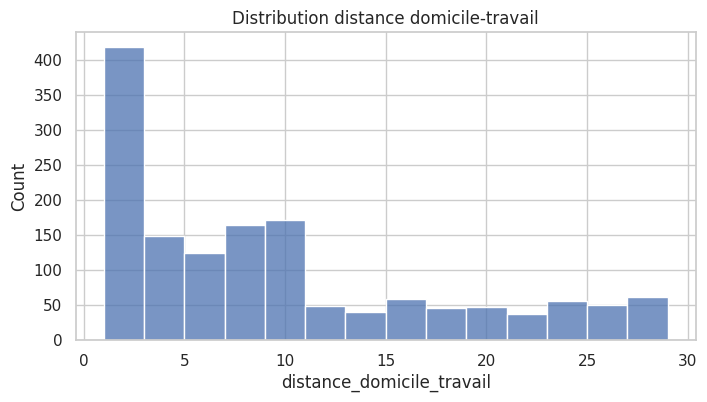

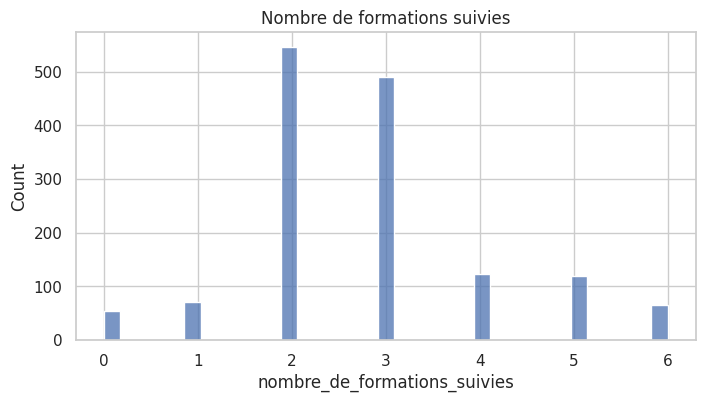

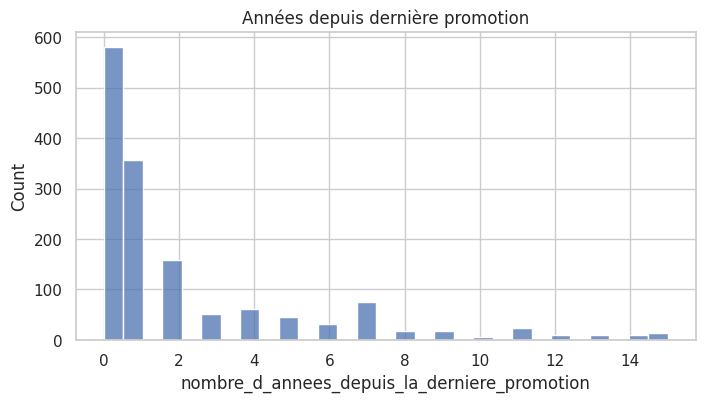

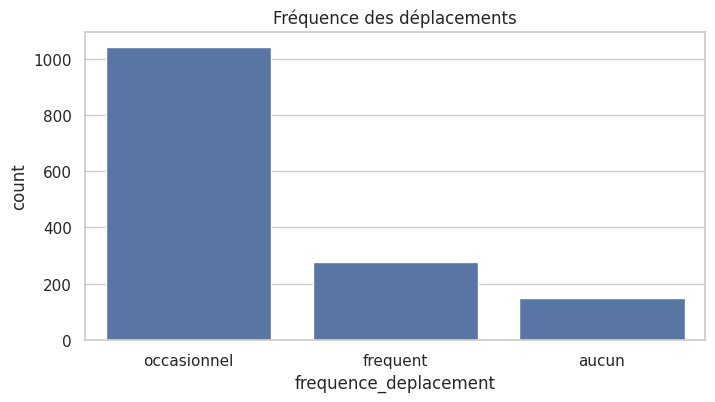

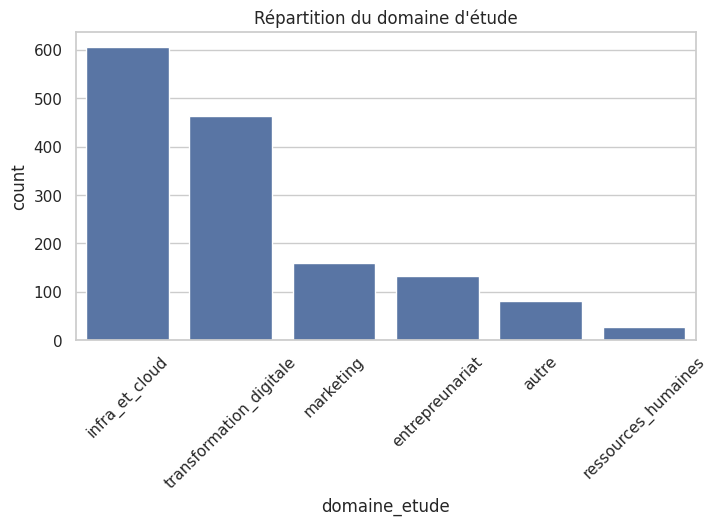

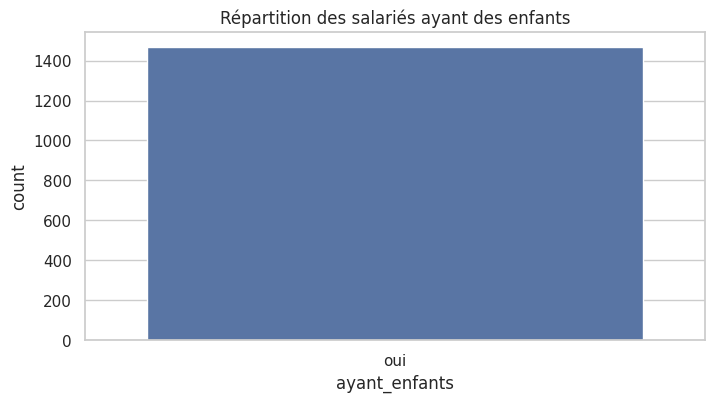

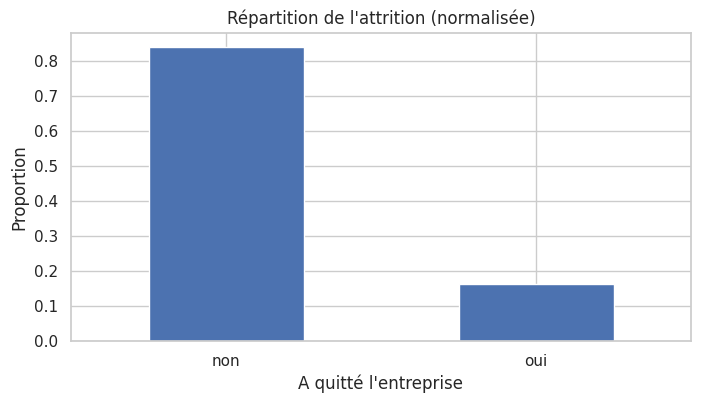

In [475]:
# Visualisations univariées

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Distance domicile-travail
sns.histplot(df_sondage["distance_domicile_travail"], kde=False)
plt.title("Distribution distance domicile-travail")
plt.show()

# Formations suivies
sns.histplot(df_sondage["nombre_de_formations_suivies"], kde=False)
plt.title("Nombre de formations suivies")
plt.show()

# Années depuis dernière promotion
sns.histplot(df_sondage["nombre_d_annees_depuis_la_derniere_promotion"], kde=False)
plt.title("Années depuis dernière promotion")
plt.show()

# Fréquence des déplacements
sns.countplot(data=df_sondage, x="frequence_deplacement")
plt.title("Fréquence des déplacements")
plt.show()

# Domaine d'étude 
sns.countplot(data=df_sondage, x="domaine_etude", order=df_sondage["domaine_etude"].value_counts().index)
plt.title("Répartition du domaine d'étude")
plt.xticks(rotation=45, ha="center")
plt.show()

# Ayant enfants
sns.countplot(data=df_sondage, x="ayant_enfants")
plt.title("Répartition des salariés ayant des enfants")
plt.show()

# a quitté l'entreprise (variable cible potentielle)
plt.figure()

(df_sondage["a_quitte_l_entreprise"]
 .value_counts(normalize=True)
 .sort_index()
 .plot(kind="bar"))

plt.title("Répartition de l'attrition (normalisée)")
plt.ylabel("Proportion")
plt.xlabel("A quitté l'entreprise")
plt.xticks(rotation=0)
plt.show()

In [476]:
# Analyse de la variable cible a_quitte_l_entreprise
df_sondage["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
non    0.838776
oui    0.161224
Name: proportion, dtype: float64

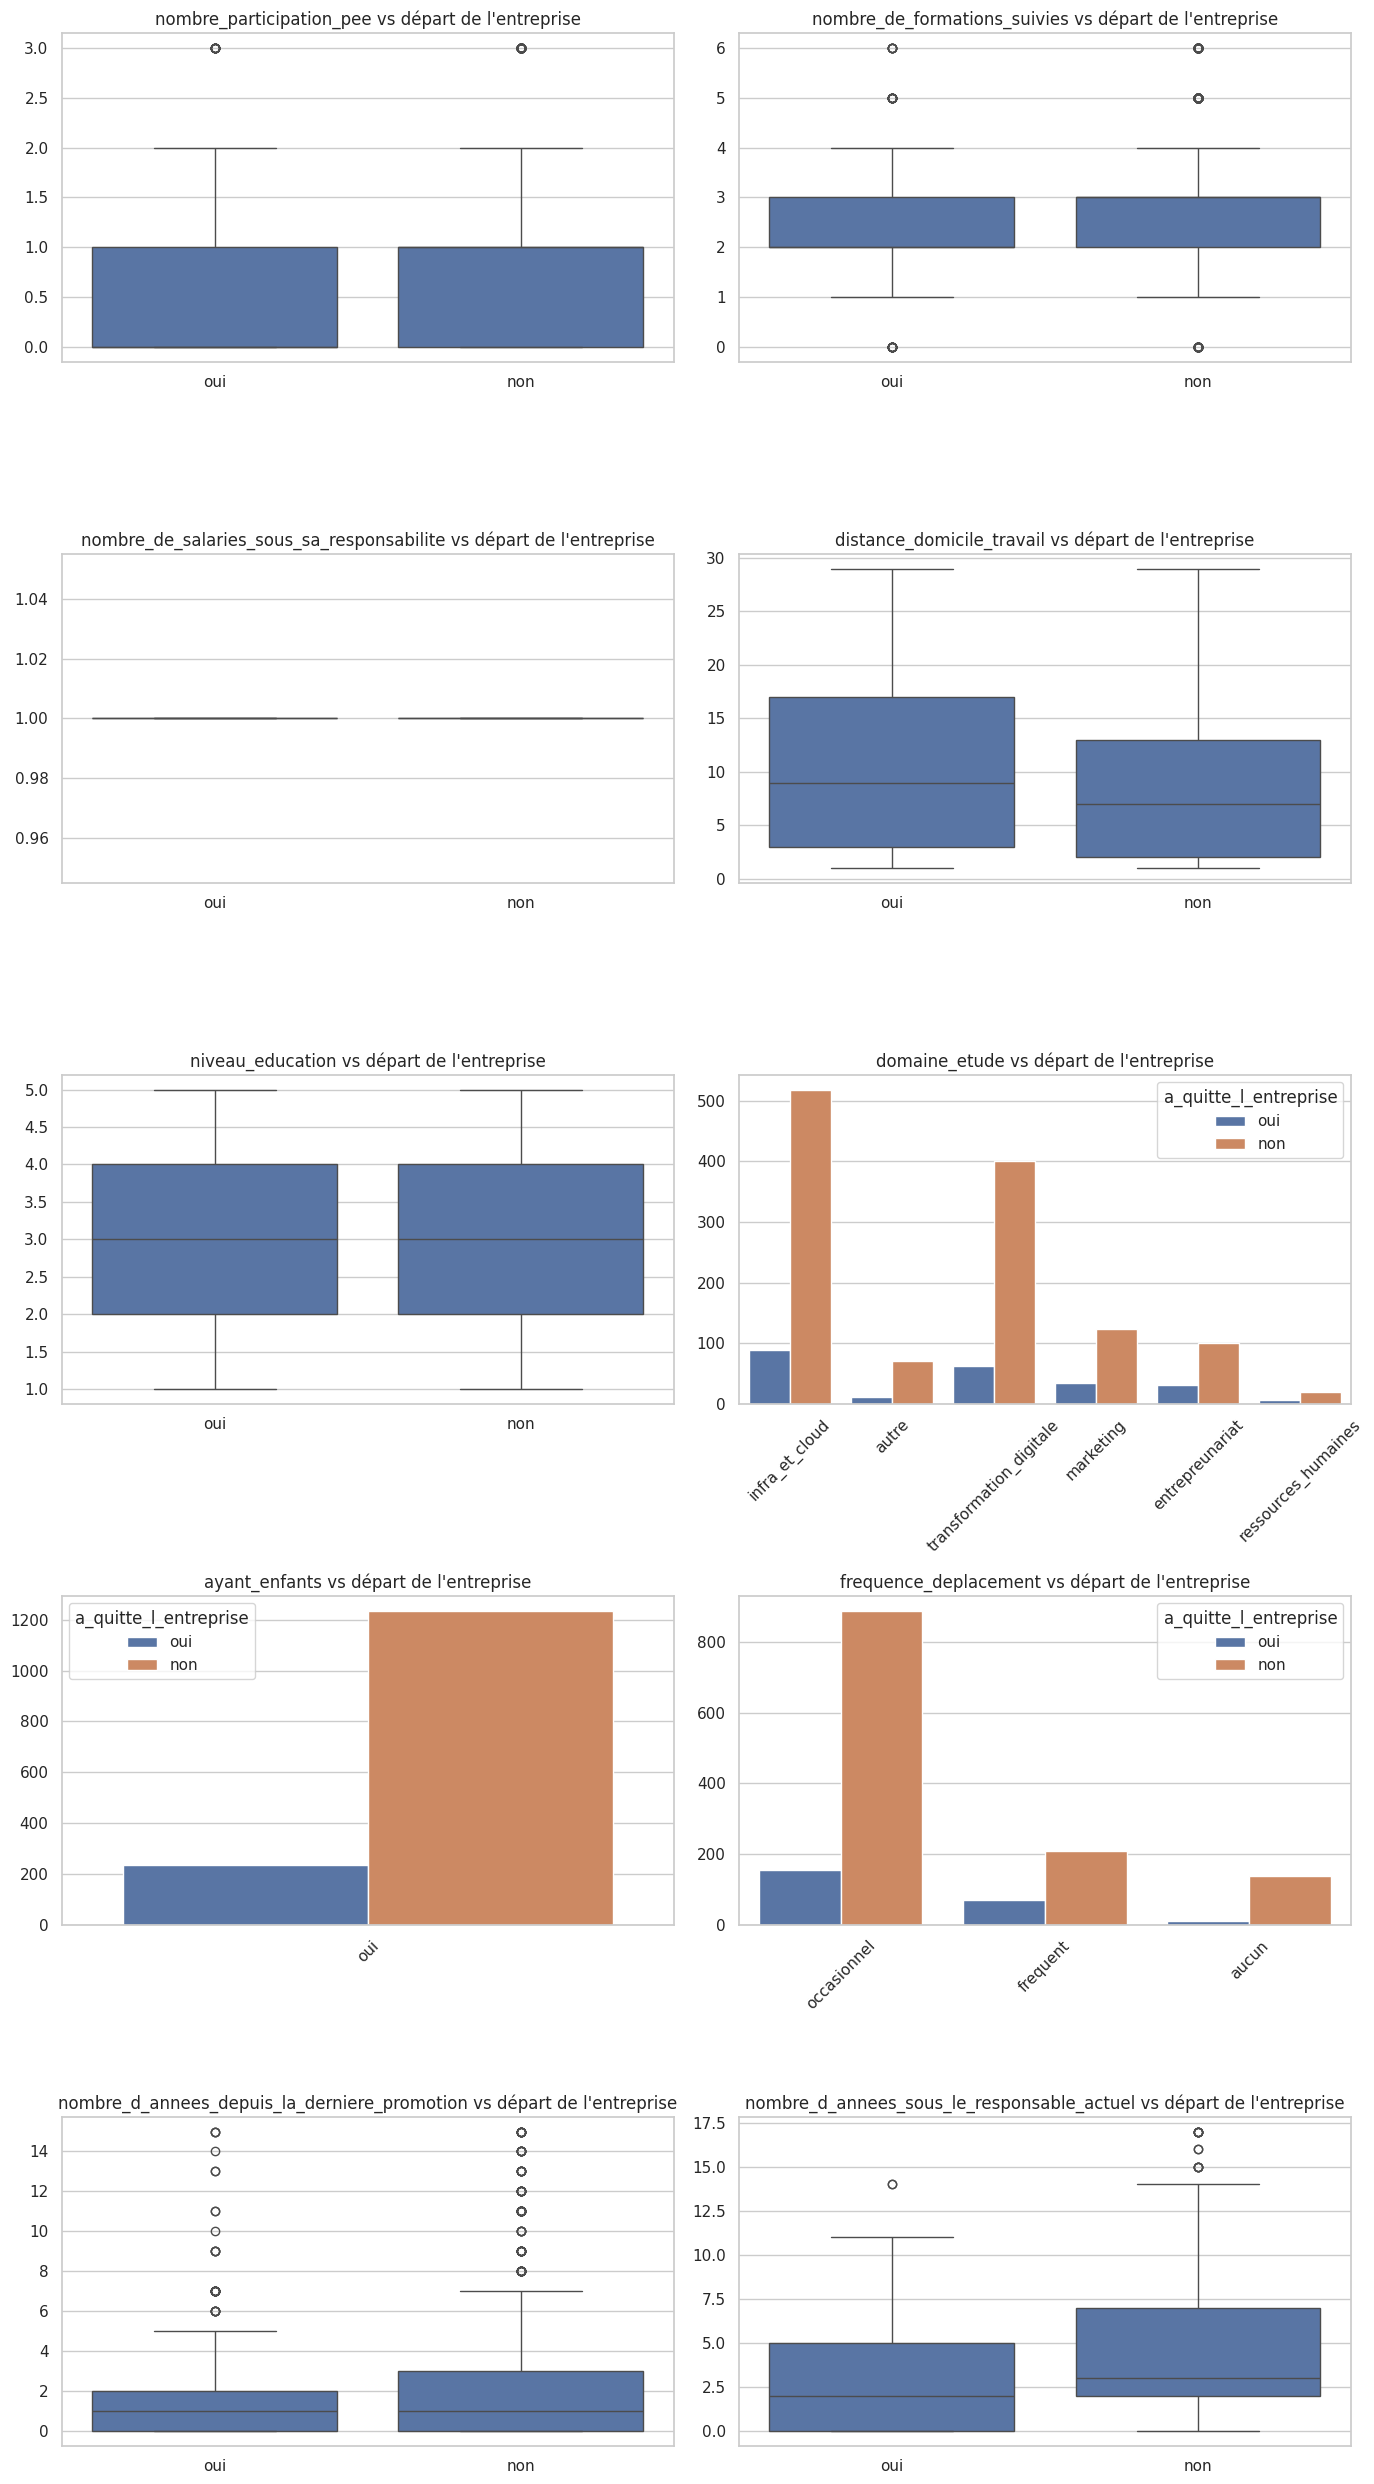

In [477]:
# visualisaitons bivariees
import math

sns.set(style="whitegrid")

cols = [
    "nombre_participation_pee",
    "nombre_de_formations_suivies",
    "nombre_de_salaries_sous_sa_responsabilite",
    "distance_domicile_travail",
    "niveau_education",
    "domaine_etude",
    "ayant_enfants",
    "frequence_deplacement",
    "nombre_d_annees_depuis_la_derniere_promotion",
    "nombre_d_annees_sous_le_responsable_actuel"
]

n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):

    # Cas variables numériques
    if df_sondage[col].dtype == "int64":
        sns.boxplot(
            data=df_sondage,
            x="a_quitte_l_entreprise",
            y=col,
            ax=axes[i]
        )
    
    # Cas variables catégorielles
    else:
        sns.countplot(
            data=df_sondage,
            x=col,
            hue="a_quitte_l_entreprise",
            ax=axes[i]
        )
        axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_title(f"{col} vs départ de l'entreprise")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# supprimer axes inutilisés
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### observations
* la colonne ayant enfants pourra être retirée du dataframe car la réponse est toujours oui, donc la variable n'apportera pas d'informations
* population plutôt proche du lieu de travail, peu de contrainte géographique globale
* politique de formation active (1000 salaries ont suivi entre 2 et 3 formations)
* promotions récentes nombreus
* déplacements assez présents ce qui peut être facteur potentiel de fatigue puis de départ de l'entreprise
* population technique dominante
* Le dataset présente un déséquilibre de classes significatif sur la variable cible, ce qui nécessitera des techniques adaptées (pondération, rééchantillonnage avec undersampling) lors de la modélisation machine learning
* plus de départs dans le domaine “infra & cloud” (profils très demandés, stress, sous-payé par rapport au marché)

L’analyse exploratoire met en évidence une population majoritairement technique (domaine infra & cloud), avec une forte concentration des départs dans ce segment. Par ailleurs, les salariés présentent une ancienneté faible depuis leur dernière promotion et une fréquence de déplacement majoritairement occasionnelle. Le dataset présente également un déséquilibre de classes (16% de départs), ce qui devra être pris en compte dans les étapes de modélisation.

In [478]:
df_sondage.drop(
    columns=[
        "ayant_enfants",
        "nombre_de_salaries_sous_sa_responsabilite"
    ],
    inplace=True
)
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   code_sondage                                  1470 non-null   int64
 4   distance_domicile_travail                     1470 non-null   int64
 5   niveau_education                              1470 non-null   int64
 6   domaine_etude                                 1470 non-null   str  
 7   frequence_deplacement                         1470 non-null   str  
 8   nombre_d_annees_depuis_la_derniere_promotion  1470 non-null   int64
 9   nombre_d_annees_sous_le_responsable_actuel    1470 non-null   int64
dtypes: int64(7), str(3)
mem

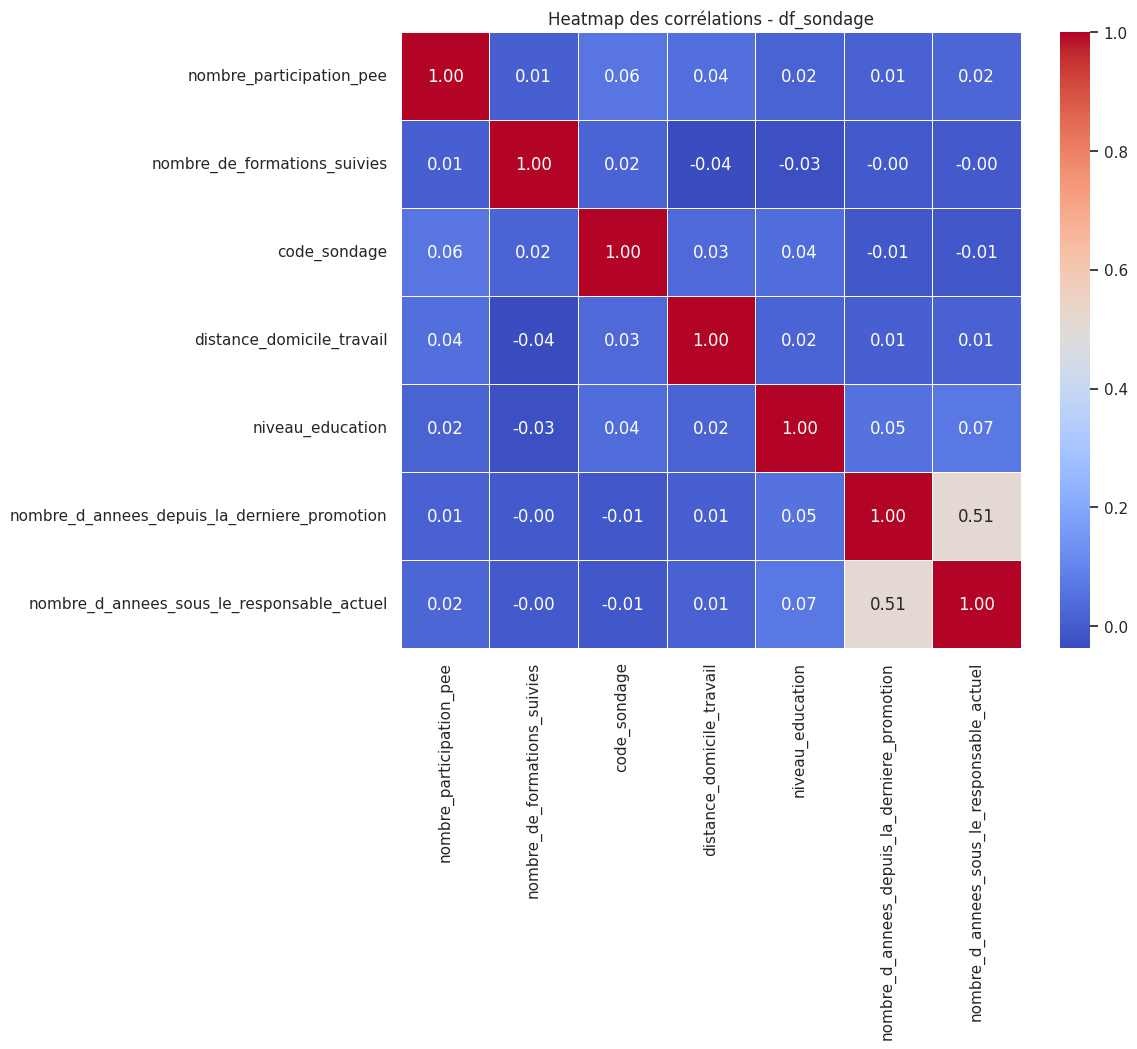

In [479]:
# Matrice globale des corrélations de df_sondage
# sélection des colonnes numériques
num_cols_sondage = df_sondage.select_dtypes(include="int64")

# matrice de corrélation
corr_matrix = num_cols_sondage.corr()

# heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap des corrélations - df_sondage")
plt.show()

#### observation
Une corrélation modérée (0.51) entre le nombre d’années depuis la dernière promotion et l’ancienneté avec le responsable actuel suggère que les salariés restés longtemps sous le même management ont tendance à connaître une progression de carrière plus lente, ce qui peut refléter une certaine stagnation professionnelle. Ceci peut être une motivation pour quitter l'entreprise.

In [480]:
# Réalisation de la jointure pour réunir les trois dataframes

df_sirh = df_sirh.rename(columns={"id_salarie": "id"})
df_eval = df_eval.rename(columns={"numero_d_evaluation": "id"})
df_sondage = df_sondage.rename(columns={"code_sondage": "id"})

df_joint = (
    df_sirh
    .merge(df_eval, on="id", how="inner")
    .merge(df_sondage, on="id", how="inner")
    .sort_values(by="id")
    .reset_index(drop=True)
)

In [481]:
# Contrôle dimensions du dataframe obtenu et de l'absence de doublons
print("Shape finale :", df_joint.shape)
print("Doublons :", df_joint.duplicated().sum())

Shape finale : (1470, 31)
Doublons : 0


In [482]:
df_joint.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   id                                            1470 non-null   int64   
 1   age                                           1470 non-null   int64   
 2   genre                                         1470 non-null   str     
 3   revenu_mensuel                                1470 non-null   int64   
 4   statut_marital                                1470 non-null   str     
 5   departement                                   1470 non-null   str     
 6   poste                                         1470 non-null   str     
 7   nombre_experiences_precedentes                1470 non-null   int64   
 8   nombre_total_annees_experience                1470 non-null   int64   
 9   nombre_total_annees_dans_l_entreprise         1470 non-null   i

#### EDA sur le dataframe df_joint (Im here)